1. 背景
在前面的分析中，我们已经完成了单细胞测序数据的预处理，包括质控，归一化，高可变基因计算，降维，可视化。我们已经可以简单地去评估我们单细胞数据的质量以及一些基本属性。但是，这并不是我们单细胞分析的目的，

<div style="color:yellow">
单细胞测序数据经过预处理后，下一步是在数据集中识别细胞结构。
</div>

在获得细胞的邻域图后，我们可以根据细胞的图结构，利用图聚类算法，将相似的细胞聚类到一起。在单细胞测序中，我们一般会使用Leiden或者Louvain算法来对单细胞数据进行聚类。由于Louvain算法不再维护了，

<div style="color:lightgreen">
所以我们一般推荐使用Leiden算法。Leiden算法通过考虑聚类中细胞之间的连接数与数据集中整体预期连接数之间的比例来创建聚类。
</div>
Clustering Overview
Leiden算法在从经过主成分降维的表达空间中获取的KNN图上进行聚类计算。它从初始分区开始，其中每个节点都属于自己的社区。接下来，算法将单个节点从一个社区移动到另一个社区，以找到一个分区，然后进行细化。基于细化后的分区，生成一个聚合网络，再次进行细化，直到无法进一步改进，达到最终分区。

<div style="color:magenta">
Leiden模块具有分辨率参数，可以确定分区簇的规模，从而确定聚类的粗细程度。
    
</div>

较高的分辨率参数会导致更多的聚类。该算法还允许通过对KNN图进行子集操作，在数据集中有效地进行特定聚类的子聚类。子聚类使用户能够在聚类中识别细胞类型特定的状态，或进行更精细的细胞类型标记[wagner_revealing_2016]，但也可能导致仅由数据中存在的噪声引起的模式。

正如前面提到的，Leiden算法已在scanpy中实现。

In [1]:
import omicverse as ov
print(f'omicverse version: {ov.__version__}')
import scanpy as sc
print(f'scanpy version: {sc.__version__}')
ov.ov_plot_set()

omicverse version: 1.7.9


/tmp/ipykernel_11632/1385324816.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'scanpy version: {sc.__version__}')


scanpy version: 1.11.5


/home/zhen/miniforge3/envs/scanpy_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3060 Laptop GPU
      Memory: 6.0 GB | Compute: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [3]:
adata = ov.read('s4d8_dimensionality_reduction.h5ad')
adata

AnnData object with n_obs × n_vars = 14814 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'log2_nUMIs', 'log2_nGenes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'REFERENCE_MANU', 'history_log', 'hvg', 'layers_counts', 'log1p', 'neighbors', 'pca', 'status', 'status_args', 'tsne', 'umap'
    obsm: 'X_mde_counts', 'X_mde_scaled', 'X_pca', 'X_pca_counts',

我们首先基于细胞的主成分scaled|original|X_pca构建邻域图，在scanpy中，KNN邻域图的构建是通过scanpy.pp.neighbors函数来完成的，我们首先选择前30个主成分来构建邻域图，通常认为前30个主成分已经捕获了数据中的绝大多数方差。不过也不绝对，在一些分析中也会设定为前50个主成分，或者前100个主成分。这取决于你的分析目的是否会受微小方差的影响。

根据您的分析目的，如果您希望使用经过预处理缩放的数据进行下游分析，应该使用 X_pca_scaled；如果您想使用原始计数数据的PCA结果，则应使用 X_pca_counts。

In [5]:
sc.pp.neighbors(adata, n_neighbors=15,
                n_pcs=30,use_rep='X_pca')
                #n_pcs=30,use_rep='scaled|original|X_pca')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)


In [6]:
sc.tl.leiden(adata)

running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


[<Axes: title={'center': 'Resolution:0.25'}, xlabel='X_mde1', ylabel='X_mde2'>,
 <Axes: title={'center': 'Resolution:0.5'}, xlabel='X_mde1', ylabel='X_mde2'>,
 <Axes: title={'center': 'Resolution:1'}, xlabel='X_mde1', ylabel='X_mde2'>,
 <Axes: title={'center': 'Resolution:2'}, xlabel='X_mde1', ylabel='X_mde2'>]

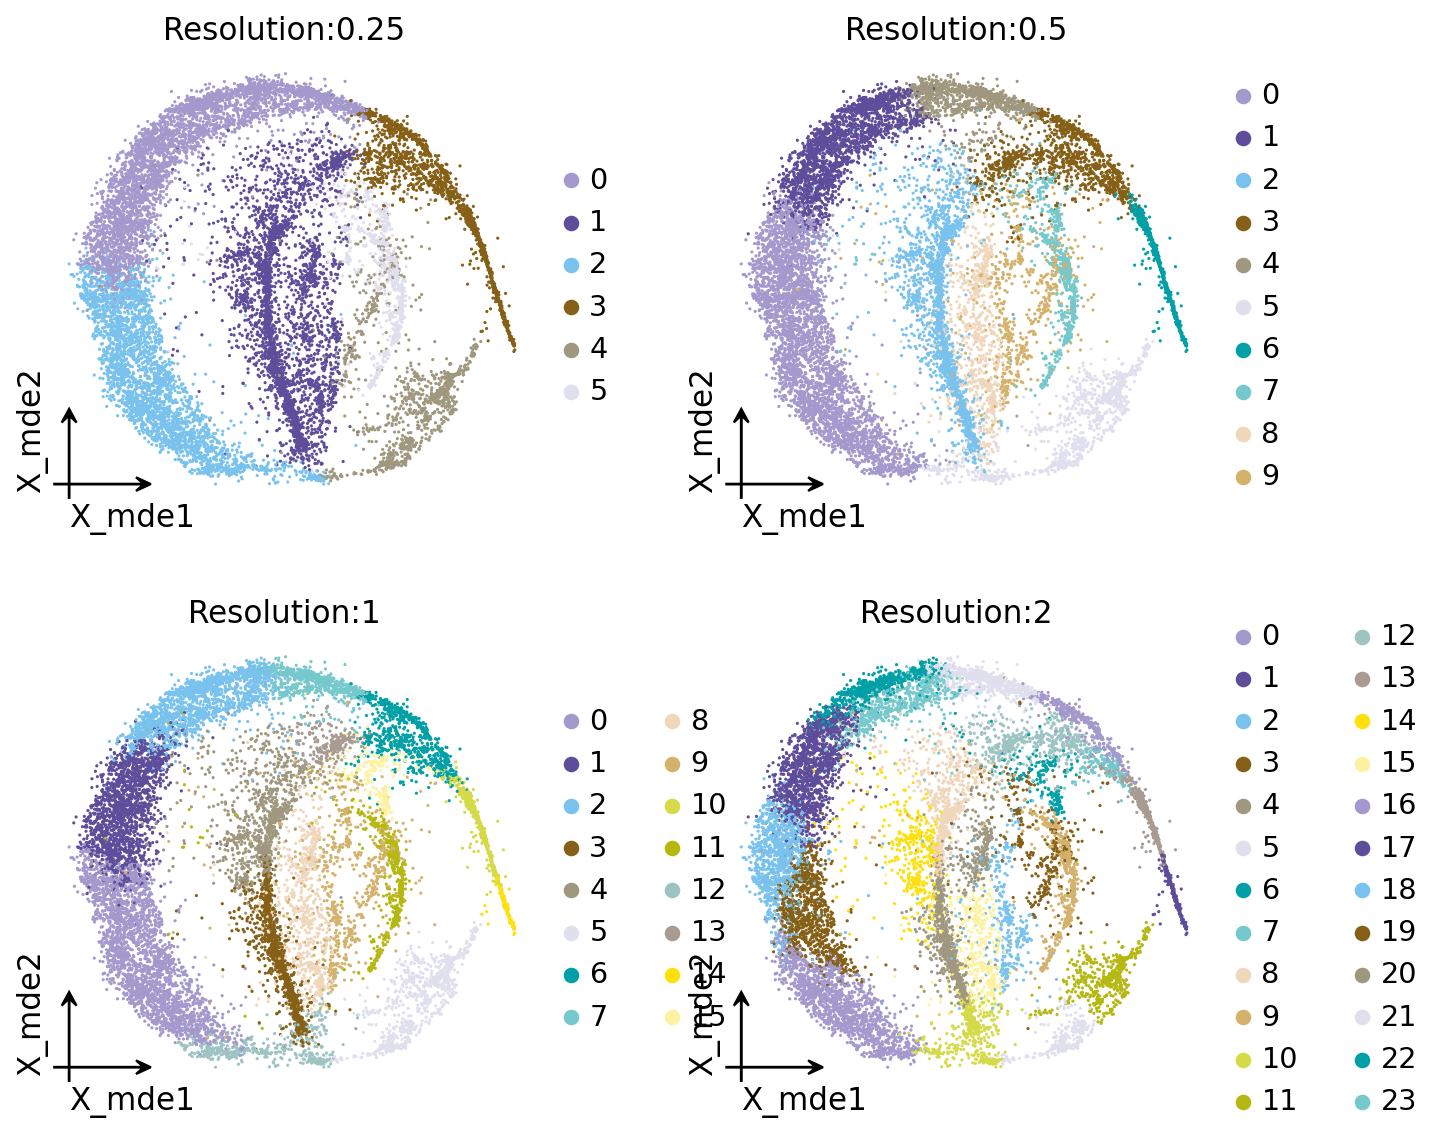

In [13]:
adata.obsm["X_mde"] = ov.utils.mde(adata.obsm["X_pca"])

leiden_keys = ["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"]
leiden_keys = [k for k in leiden_keys if k in adata.obs]  # 修改说明: only keep existing leiden keys
leiden_titles = ["Resolution:0.25", "Resolution:0.5", "Resolution:1", "Resolution:2"]
leiden_titles = [t for k, t in zip(["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"], leiden_titles) if k in adata.obs]  # 修改说明: align titles with existing keys
if not leiden_keys:
    leiden_keys = ["leiden"]  # 修改说明: fallback to default leiden if custom keys missing
    leiden_titles = ["leiden"]
ov.utils.embedding(adata,
                basis='X_mde',
                color=leiden_keys,  # 修改说明: avoid missing leiden keys
                title=leiden_titles,  # 修改说明: match titles to available keys
                palette=ov.palette()[12:],
                ncols=2,
                show=False,frameon='small')